In [10]:
import sqlite3

connection = sqlite3.connect(r'../../data/raw/db.sqlite3')

cursor = connection.cursor()

### Retriving led data and meaning

In [24]:
placement_roles = "SELECT * FROM placement_roles LIMIT 4" 

cursor.execute(placement_roles)

result = cursor.fetchall()

print("------- QUERY RESULTS -------")
for row in result:
    print(f"id: {row[0]} || product_id: {row[1]} || name: {row[3]}")

------- QUERY RESULTS -------
id: 12 || product_id: 1 || name: start
id: 13 || product_id: 1 || name: middle
id: 14 || product_id: 1 || name: finish
id: 15 || product_id: 1 || name: foot


### Retriving climb and climb_stat data

In [ ]:
query = """
SELECT 
    climbs.name,
    climbs.layout_id,
    climb_stats.angle,
    climb_stats.difficulty_average,
    climbs.frames,
    difficulty_grades.boulder_name
FROM climbs
JOIN climb_stats ON climbs.uuid = climb_stats.climb_uuid
JOIN difficulty_grades
ON ROUND(climb_stats.difficulty_average) = difficulty_grades.difficulty
LIMIT 4;
"""

cursor.execute(query)

result = cursor.fetchall()

print("------- QUERY RESULTS -------")
for row in result:
    print(f"Name: {row[0]} || Layout_id: {row[1]} || Angle: {row[2]} || Difficulty: {row[3]}, {row[5]}")
    print(f"Frames: {row[4]}")
    print()

------- QUERY RESULTS -------
Name: NuVu || Layout_id: 1 || Angle: 50 || Difficulty: 16.0, 6a/V3
Frames: p1084r15p1086r15p1110r12p1146r12p1161r13p1197r13p1216r13p1231r13p1249r13p1268r13p1281r13p1318r13p1333r13p1351r14p1476r15p1484r15p1487r15p1504r15p1505r15p1522r15p1530r15p1541r15p1548r15p1567r15p1576r15

Name: the blake || Layout_id: 1 || Angle: 35 || Difficulty: 16.0, 6a/V3
Frames: p1148r15p1150r12p1165r13p1168r12p1183r13p1200r13p1234r13p1250r13p1284r13p1301r13p1302r13p1319r13p1336r13p1353r13p1370r13p1387r14

Name: train 1 || Layout_id: 1 || Angle: 5 || Difficulty: 12.0, 4c/V0
Frames: p1094r15p1141r12p1179r13p1209r13p1216r13p1228r13p1248r13p1272r13p1285r13p1301r13p1324r13p1394r14p1464r15p1467r15p1477r15p1493r15p1503r15p1506r15p1515r15p1527r15p1539r15p1563r15

Name: Abradolf Lincler || Layout_id: 1 || Angle: 10 || Difficulty: 13.6364, 5b/V1
Frames: p1073r15p1172r12p1241r13p1271r13p1322r13p1371r13p1389r14p1471r15p1482r15p1518r12p1526r15



### Exploring holes data

In [ ]:
query="""
SELECT 
Max(x), Max(y),
Min(x), Min(y)
FROM holes
WHERE 
holes.product_id = 1
"""
cursor.execute(query)

result = cursor.fetchall()
print("------- QUERY RESULTS -------")
print(f"Max X: {result[0][0]} || Max Y: {result[0][1]}")
print(f"Min X: {result[0][2]} || Min Y: {result[0][3]}")

board_width = result[0][0] - result[0][2] + 1
board_heigth = result[0][1] - result[0][3] + 1

print()
print(f"Board height: {board_heigth} || Board width: {board_width}")

------- QUERY RESULTS -------
Max X: 164 || Max Y: 176
Min X: -20 || Min Y: 4

Board height: 173 || Board width: 185


### Retriving holds positions

In [69]:
query = """
SELECT
    placements.id, 
    holes.x,
    holes.y
FROM placements
JOIN holes 
ON placements.hole_id = holes.id
WHERE 
placements.set_id = 1
Limit 4;
"""

cursor.execute(query)

result = cursor.fetchall()

print("------- QUERY RESULTS -------")
for row in result: 
    print(f"Hold id: {row[0]} || X: {row[1]} || Y: {row[2]}")



------- QUERY RESULTS -------
Hold id: 1073 || X: 136 || Y: 8
Hold id: 1074 || X: 128 || Y: 8
Hold id: 1075 || X: 120 || Y: 8
Hold id: 1076 || X: 112 || Y: 8


### Data visualisation to further understand the database

In [99]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

query = """
SELECT 
    climbs.name,
    climb_stats.angle,
    climb_stats.difficulty_average,
    climb_stats.ascensionist_count as repeats,
    difficulty_grades.boulder_name as grade,
    climbs.frames
FROM climbs
JOIN climb_stats ON climb_stats.climb_uuid = climbs.uuid
JOIN difficulty_grades ON difficulty_grades.difficulty = ROUND(climb_stats.difficulty_average)
"""

df = pd.read_sql_query(query, connection)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 323397 entries, 0 to 323396
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                323397 non-null  str    
 1   angle               323397 non-null  int64  
 2   difficulty_average  323397 non-null  float64
 3   repeats             323397 non-null  int64  
 4   grade               323397 non-null  str    
 5   frames              323397 non-null  str    
dtypes: float64(1), int64(2), str(3)
memory usage: 14.8 MB


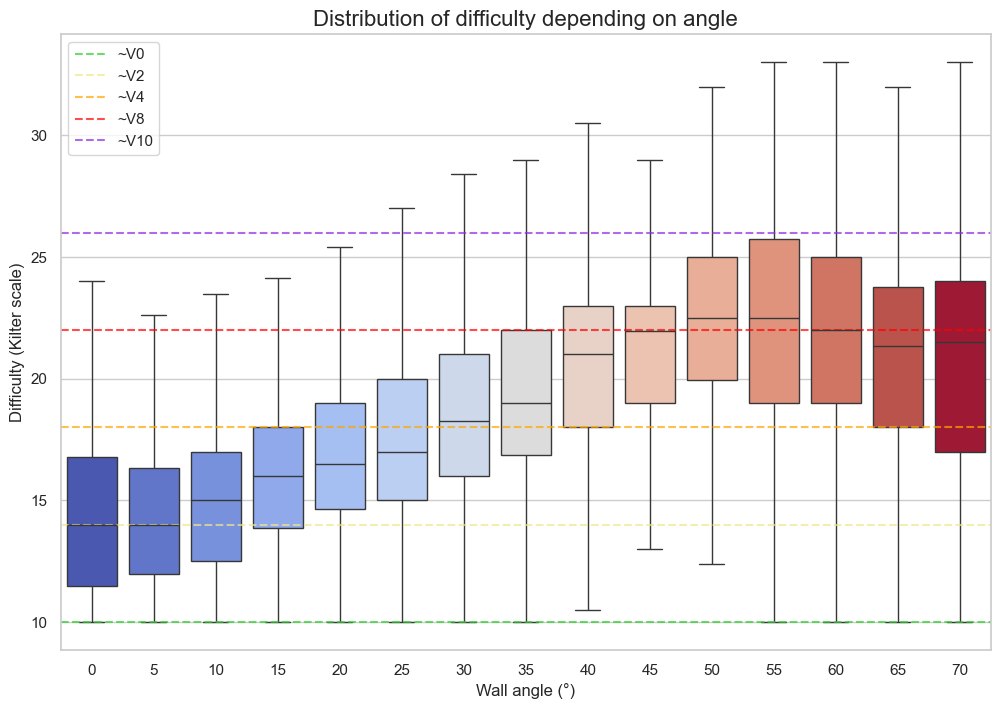

In [92]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df, 
    x='angle', 
    y='difficulty_average', 
    palette="coolwarm",
    legend=False,
    hue="angle",
    showfliers=False
)


plt.title('Distribution of difficulty depending on angle', fontsize=16)
plt.xlabel('Wall angle (°)', fontsize=12)
plt.ylabel('Difficulty (Kilter scale)', fontsize=12)

plt.axhline(y=10, color='limegreen', linestyle='--', alpha=0.7, label='~V0')
plt.axhline(y=14, color='khaki', linestyle='--', alpha=0.7, label='~V2')
plt.axhline(y=18, color='orange', linestyle='--', alpha=0.7, label='~V4')
plt.axhline(y=22, color='red', linestyle='--', alpha=0.7, label='~V8')
plt.axhline(y=26, color='blueviolet', linestyle='--', alpha=0.7, label='~V10')
plt.legend(loc='upper left')

/var/folders/3t/djm91gb11r530llm5zx7lpdm0000gn/T/ipykernel_41169/1197431947.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='grade', order=order, palette="flare")
/Users/janmichorek/Documents/ProgrammingProjects/KilterClimbGeneration/kilter_env/lib/python3.13/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname V identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


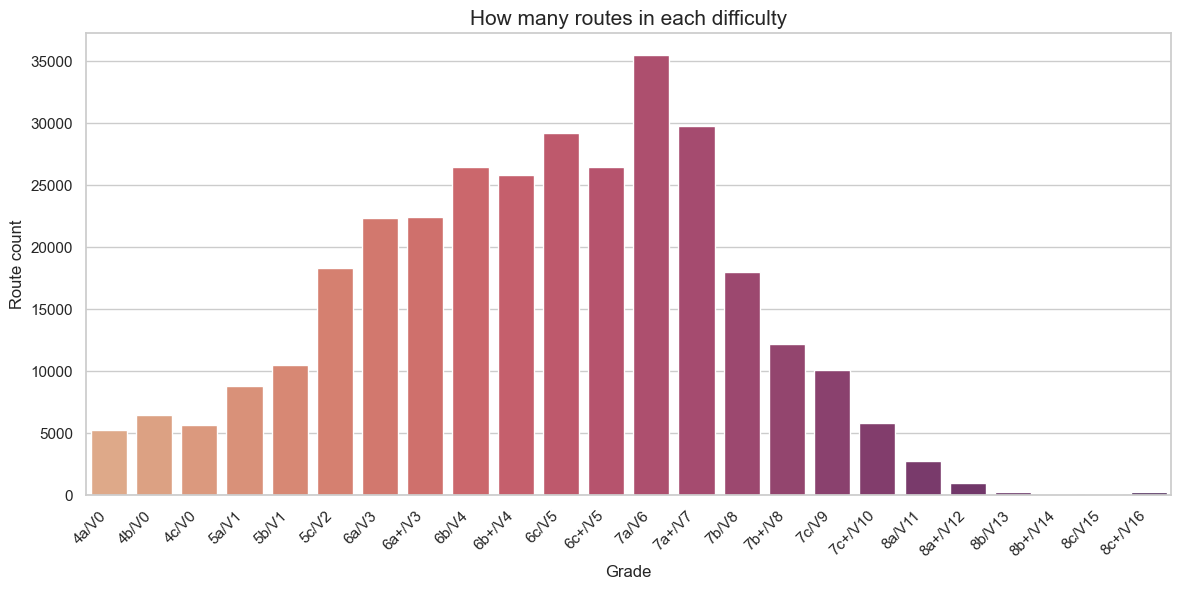

In [110]:
order = df.sort_values('difficulty_average')['grade'].unique()

plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='grade', order=order, palette="flare")
plt.title('How many routes in each difficulty', fontsize=15)
plt.xlabel('Grade')
plt.ylabel('Route count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [137]:
query_multi_angle = """
SELECT 
    climb_stats.angle,
    difficulty_grades.boulder_name as grade,
    climb_stats.difficulty_average
FROM climbs
JOIN climb_stats ON climbs.uuid = climb_stats.climb_uuid
JOIN difficulty_grades ON ROUND(climb_stats.difficulty_average) = difficulty_grades.difficulty
WHERE climb_stats.angle IN (30, 40, 50, 60) 
"""

df_multi = pd.read_sql_query(query_multi_angle, connection)

order = df_multi.sort_values('difficulty_average')['grade'].unique()

/Users/janmichorek/Documents/ProgrammingProjects/KilterClimbGeneration/kilter_env/lib/python3.13/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname V identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


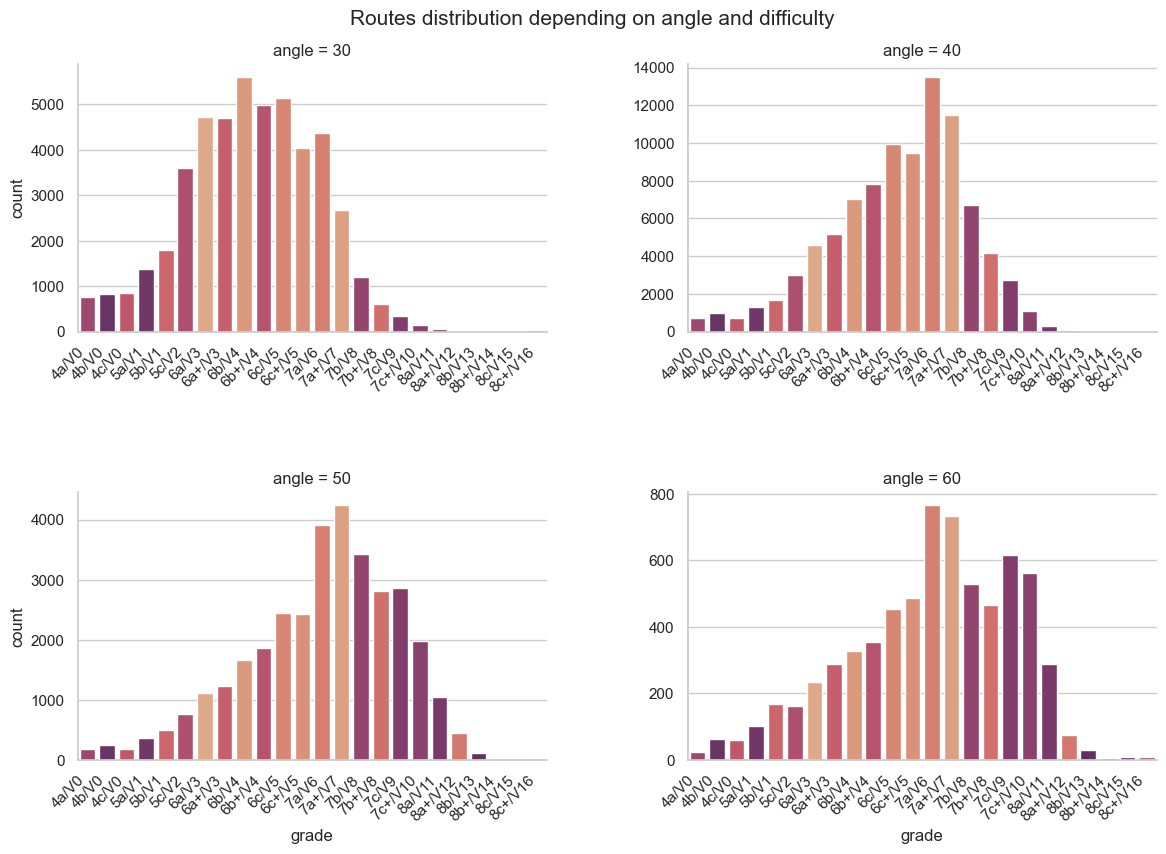

In [142]:
plot = sns.catplot(
    data = df_multi,
    x = 'grade',
    col = 'angle',
    kind = 'count',
    col_wrap=2,
    order=order,
    hue = 'grade',
    palette="flare", 
    legend=False,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=False,
)


plot.figure.suptitle("Routes distribution depending on angle and difficulty", y = 1.02, fontsize=15)
plt.subplots_adjust(hspace=0.6, wspace=0.3)
plot.set_xticklabels(rotation=45, ha='right')

plt.show()    

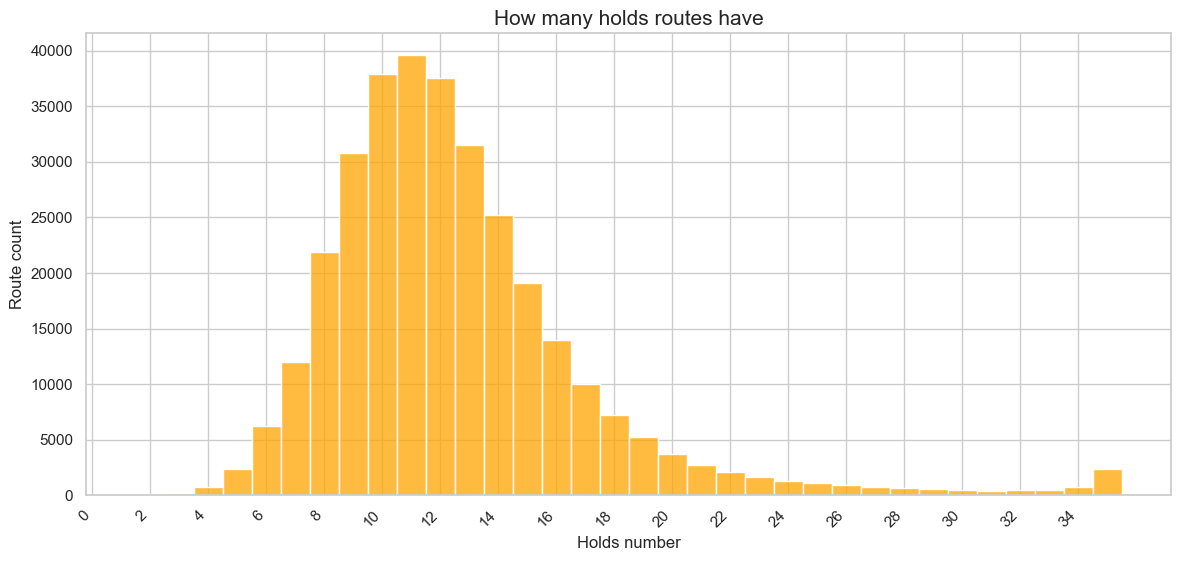

In [154]:
df['move_count'] = df['frames'].apply(lambda x: x.count('p') if x else 0)
plt.figure(figsize=(14, 6))

sns.histplot(
    data=df[df['move_count'] <= 35],
    x='move_count',
    color="orange",
    discrete=True,
    )
plt.title('How many holds routes have', fontsize=15)
plt.xlabel('Holds number')
plt.ylabel('Route count')
plt.xticks(rotation=45, ha='right')
plt.xticks(range(0, 36, 2))
plt.show()